# Path2Space vs clinical biomarkers

Compares the Path2Space pCR predictor against established clinical / molecular
biomarkers (Shulman et al., *Cell* 2026), for chemotherapy and trastuzumab in
TransNEO and PBCP.

Predictors: **P2S** (Path2Space), **Sammut-ML**, **ENLIGHT**, **HER2 SPAND**
(ERBB2-pathway spatial heterogeneity), **ERBB2** expression, **Ki67**,
**Cytolytic** score, and **IFN-γ** signature.

Per-sample scores for every predictor are shipped in
`../data/clinical_biomarker_scores.csv` (`cohort`, `treatment`, `Response`,
and one column per predictor). Biomarker scores were computed from bulk
expression (Ki67 = MKI67; Cytolytic = mean of GZMA, PRF1; IFN-γ = mean z-score
of a 10-gene signature; ERBB2 = ERBB2 expression); HER2 SPAND is the
ErbB-pathway Moran's-I spatial-heterogeneity score.

## Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

def auc_ci(y, p, n_boot=2000, seed=123):
    """AUC with a stratified-bootstrap 95% CI."""
    y, p = np.asarray(y), np.asarray(p)
    auc = roc_auc_score(y, p)
    rng = np.random.default_rng(seed)
    pos, neg = np.flatnonzero(y == 1), np.flatnonzero(y == 0)
    boot = []
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(pos, len(pos), replace=True),
                              rng.choice(neg, len(neg), replace=True)])
        if len(np.unique(y[idx])) == 2:
            boot.append(roc_auc_score(y[idx], p[idx]))
    return auc, np.percentile(boot, 2.5), np.percentile(boot, 97.5)

MODEL_NAME = {"P2S": "P2S", "Sammut-ML": "Sammut-ML", "ENLIGHT": "ENLIGHT",
              "SPAND": "HER2 SPAND", "HER2_score": "ERBB2", "Ki67_score": "Ki67",
              "CYT_score": "Cytolytic", "IFNG_score": "IFN-\u03b3"}
MODEL_COLORS = {"HER2 SPAND": "#d0bbff", "P2S": "#7570b3", "ENLIGHT": "#66a61e",
                "Sammut-ML": "#e6ab02", "Cytolytic": "#1b9e77", "IFN-\u03b3": "#d95f02",
                "Ki67": "#e7298a", "ERBB2": "#fab0e4"}

## Load per-sample predictor scores

In [2]:
meta = pd.read_csv("../data/clinical_biomarker_scores.csv", index_col=0)
print(meta.groupby(["cohort", "treatment"]).size().to_dict())
meta.head()

{('PBCP', 'chemo'): 38, ('PBCP', 'trastuzumab'): 36, ('TransNEO', 'chemo'): 93, ('TransNEO', 'trastuzumab'): 61}


,cohort,treatment,Response,Ki67_score,CYT_score,IFNG_score,HER2_score,SPAND,Sammut-ML,P2S,ENLIGHT
slide_name,,,,,,,,,,,
BC_00000_470650,TransNEO,trastuzumab,0.0,2.122720,0.631840,-0.289632,3.922063,-0.048764,0.307014,1.182733,0.536992
BC_00001_470651,TransNEO,chemo,1.0,1.999507,1.515238,-0.211715,2.327689,NaN,0.293332,0.280213,NaN
BC_00002_470652,TransNEO,trastuzumab,1.0,2.140660,1.721654,-0.185510,3.150723,-0.109614,0.421805,1.755200,0.554722
BC_00003_470653,TransNEO,chemo,0.0,2.105759,1.216386,-0.198505,2.457521,NaN,0.375374,0.633584,NaN
BC_00004_470654,TransNEO,chemo,0.0,2.072996,0.899530,-0.280742,2.488726,NaN,0.137739,0.009122,NaN


## AUC and bootstrap CI per cohort, treatment and predictor

ERBB2 expression is evaluated for trastuzumab only (not informative for the
chemotherapy contrast).

In [3]:
rows = []
for (cohort, treatment), g in meta.groupby(["cohort", "treatment"]):
    for col, name in MODEL_NAME.items():
        if col not in g.columns:
            continue
        if name == "ERBB2" and treatment == "chemo":
            continue
        sub = g[["Response", col]].dropna()
        if len(sub) < 5 or sub["Response"].nunique() < 2:
            continue
        auc, lo, hi = auc_ci(sub["Response"], sub[col])
        rows.append({"cohort": cohort, "treatment": treatment, "model": name,
                     "n": len(sub), "auc": auc, "ci_low": lo, "ci_high": hi})
results = pd.DataFrame(rows)
results.round(3)

,cohort,treatment,model,n,auc,ci_low,ci_high
0,PBCP,chemo,P2S,19,0.886,0.714,1.000
1,PBCP,chemo,Sammut-ML,19,0.771,0.557,0.943
2,PBCP,chemo,Ki67,19,0.843,0.643,1.000
3,PBCP,chemo,Cytolytic,19,0.886,0.700,1.000
4,PBCP,chemo,IFN-γ,19,0.886,0.686,1.000
5,PBCP,trastuzumab,P2S,18,0.896,0.701,1.000
6,PBCP,trastuzumab,Sammut-ML,18,0.831,0.584,0.987
7,PBCP,trastuzumab,HER2 SPAND,18,0.688,0.390,0.922
8,PBCP,trastuzumab,ERBB2,18,0.714,0.416,0.961
9,PBCP,trastuzumab,Ki67,18,0.688,0.390,0.935


## Figure — AUC by predictor

Four panels (TransNEO / PBCP x chemotherapy / trastuzumab); predictors sorted
by AUC; error bars are the bootstrap 95% CI. P2S bars are outlined in black.

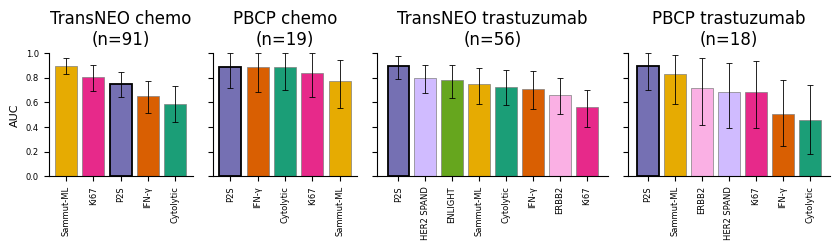

In [4]:
panels = [("TransNEO", "chemo"), ("PBCP", "chemo"),
          ("TransNEO", "trastuzumab"), ("PBCP", "trastuzumab")]

fig, axes = plt.subplots(1, 4, figsize=(8.5, 2.6), sharey=True,
                         gridspec_kw={"width_ratios": [5, 5, 8, 7]})
for ax, (cohort, treatment) in zip(axes, panels):
    g = results[(results.cohort == cohort) & (results.treatment == treatment)]
    g = g.sort_values("auc", ascending=False)
    x = np.arange(len(g))
    yerr = np.vstack([g["auc"] - g["ci_low"], g["ci_high"] - g["auc"]])
    bars = ax.bar(x, g["auc"], color=[MODEL_COLORS[m] for m in g["model"]],
                  edgecolor="grey", linewidth=0.5,
                  yerr=yerr, error_kw=dict(elinewidth=0.6, capsize=2, capthick=0.6,
                                           ecolor="black"))
    for bar, m in zip(bars, g["model"]):
        if m == "P2S":
            bar.set_edgecolor("black"); bar.set_linewidth(1.3)
    n = g["n"].iloc[0]
    ax.set(ylim=(0, 1.0), xticks=x, title=f"{cohort} {treatment}\n(n={n})")
    ax.set_xticklabels(g["model"], rotation=90, fontsize=6)
    ax.tick_params(axis="y", labelsize=6)
axes[0].set_ylabel("AUC", fontsize=8)
for sp in ["top", "right"]:
    [ax.spines[sp].set_visible(False) for ax in axes]
fig.tight_layout()
plt.show()

## Summary

In [5]:
results.pivot_table(index=["treatment", "cohort"], columns="model", values="auc").round(3)

model                 Cytolytic  ENLIGHT  ERBB2  HER2 SPAND  IFN-γ   Ki67  \
treatment   cohort                                                          
chemo       PBCP          0.886      NaN    NaN         NaN  0.886  0.843   
            TransNEO      0.590      NaN    NaN         NaN  0.649  0.805   
trastuzumab PBCP          0.455      NaN  0.714       0.688  0.506  0.688   
            TransNEO      0.724    0.784  0.660       0.798  0.707  0.560   

model                   P2S  Sammut-ML  
treatment   cohort                      
chemo       PBCP      0.886      0.771  
            TransNEO  0.753      0.898  
trastuzumab PBCP      0.896      0.831  
            TransNEO  0.894      0.748